In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
from sklearn import linear_model
import seaborn as sns
import random 
import statistics 
import math 
import scipy as sc
from scipy.stats import chisquare
from collections import Counter
from scipy.stats import ks_2samp

random.seed(42)

## Task 7

In [5]:
def continous_time_state_distribution(n, Q):
    survival_distribution = []
    states = []

    for _ in range(n):
        state = 0 
        survivaltime = 0
        while state != 4:
            transition_time = np.random.exponential(1/-Q[state][state])
            survivaltime += transition_time

            prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
            state = np.random.choice(np.arange(state+1, 5), p=prop_list)

        survival_distribution.append(survivaltime)

    mean_survival_time = np.mean(survival_distribution)

    return survival_distribution, mean_survival_time

In [6]:
n_women = 1000
Q = np.array([
    [-0.0085,  0.005,  0.0025, 0,      0.001],
    [0,      -0.014,   0.005,  0.004,  0.005],
    [0,       0,      -0.008,  0.003,  0.005],
    [0,       0,       0,     -0.009,  0.009],
    [0,       0,       0,      0,      0]
])

survival_distribution, mean_survival_time = continous_time_state_distribution(n_women, Q)

In [7]:
mean_survival_time

254.83402835236805

Text(0.5, 1.0, 'Lifetime Distribution of Women after Surgery')

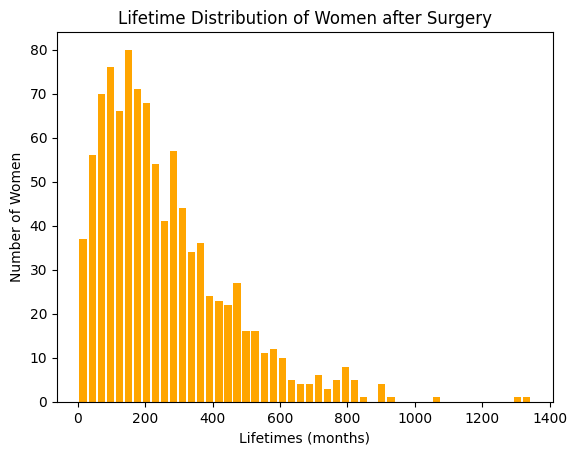

In [8]:
plt.hist(survival_distribution, bins=50, rwidth=0.8, color="orange")
plt.xlabel('Lifetimes (months)')
plt.ylabel('Number of Women')
plt.title('Lifetime Distribution of Women after Surgery')

In [9]:
std = np.std(survival_distribution)
confidence_interval = (mean_survival_time - 1.96 * std / np.sqrt(n_women), mean_survival_time + 1.96 * std / np.sqrt(n_women))
confidence_interval, mean_survival_time, std

((243.08047408085338, 266.5875826238827),
 254.83402835236805,
 189.63266377748712)

In [10]:
def continous_time_state_distribution_distant(n, Q):
    survival_distribution = []
    distant_after_t = []

    for _ in range(n):
        state = 0 
        survival_time = 0
        while state != 4:
            transition_time = np.random.exponential(1/-Q[state][state])
            survival_time += transition_time

            prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
            state = np.random.choice(np.arange(state+1, 5), p=prop_list)

            if (state in [2,3]) & (survival_time > 30.5):
                distant_after_t.append(True)


        survival_distribution.append(survival_time)

    distant_fraction = sum(distant_after_t) / n
    mean_survival_time = np.mean(survival_distribution)

    return survival_distribution, distant_fraction, mean_survival_time

In [11]:
survival_distribution, distant_fraction, mean_survival_time = continous_time_state_distribution_distant(n_women, Q)

In [12]:
print(f"Distant fraction after 30.5 months: {distant_fraction}")

Distant fraction after 30.5 months: 0.785


## 8

In [13]:
p0 = np.array([1,0,0,0])
Qs = Q[:4,:4]

def F(t):
    return float((1- p0 @ sc.linalg.expm(Qs * t) @ np.ones(4)))

theoretical = [F(t) for t in range(1000)]

In [15]:
def continous_time_state_distribution(n, Q):
    survival_distribution = []
    states = []

    for _ in range(n):
        state = 0 
        survivaltime = 0
        while state != 4:
            transition_time = np.random.exponential(1/-Q[state][state])
            survivaltime += transition_time

            prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
            state = np.random.choice(np.arange(state+1, 5), p=prop_list)

        survival_distribution.append(survivaltime)

    mean_survival_time = np.mean(survival_distribution)

    N = len(survival_distribution)
    empirical_cdf = [sum(dead <= t for dead in survival_distribution) / len(survival_distribution) for t in range(n)]

    return survival_distribution, mean_survival_time, empirical_cdf

Text(0.5, 1.0, '')

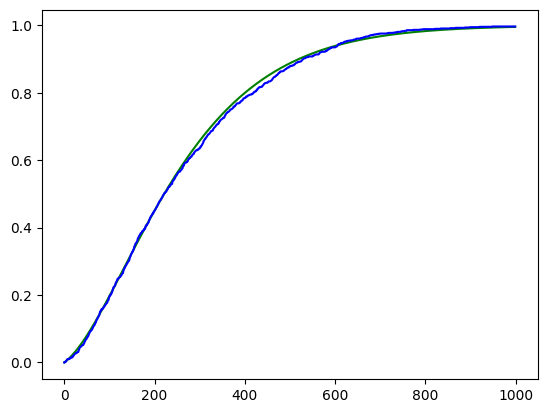

In [19]:
survival_distribution, mean_survival_time, empirical_cdf = continous_time_state_distribution(n_women, Q)

theoritical_cdf = [F(t) for t in range(1000)]

plt.plot(theoritical_cdf, color="green")
plt.plot(empirical_cdf, color="blue", label='empirical cdf')

plt.title('')

In [ ]:
#ks test
F_vec = np.vectorize(F)
ks_stat, p_value = stats.ks_1samp(survival_distribution, F_vec)
print(f"KS statistic: {ks_stat:.4f}, p-value: {p_value:.4f}")

## 9

Kaplan Meier subtracts the number of observed from the d(t) as it accounts for not knowing some units outcome. E.g. if we simulated women, till time month = 120, and then stopped, we would not know the outcome of some woman. Therefore in Kaplan Meier the N is subtracted as prevents under/over counting. However as this simulation is build up around simulating every woman to the end, and not a specific time step. The KM estimate of S(t) reduces to 1 minus the empirical cdf. 

cdf --> what proportion of all simulated women are dead at time t 
S(t) --> what proportion of all simulated women are alive at time t 

In [20]:
n_women = 1000
survival_distribution, mean_survival_time, empirical = continous_time_state_distribution(n_women, Q)
S = [1 - empirical[i] for i in range(len(empirical))]

theoritical_cdf = [F(t) for t in range(1200)]
theoritical_survival = [1 - theoritical_cdf[i] for i in range(len(theoritical_cdf))] 

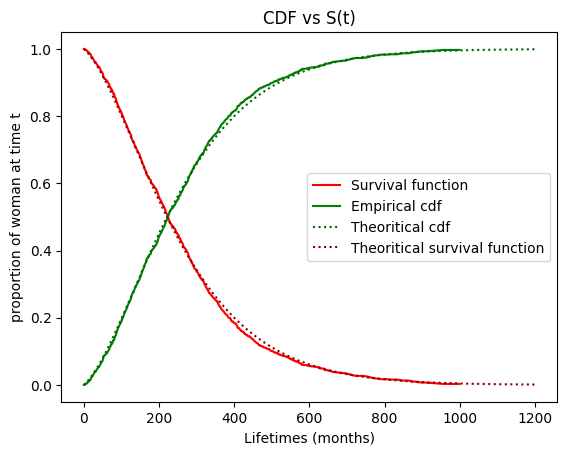

In [21]:
plt.plot(S, color="red", label='Survival function')
plt.plot(empirical, color="green", label='Empirical cdf')
plt.plot(theoritical_cdf, color='darkgreen',linestyle = 'dotted',label='Theoritical cdf')
plt.plot(theoritical_survival, color='darkred',linestyle = 'dotted',label='Theoritical survival function')

plt.plot
plt.xlabel('Lifetimes (months)')
plt.ylabel('proportion of woman at time t')
plt.legend()
plt.title('CDF vs S(t)')
plt.show()

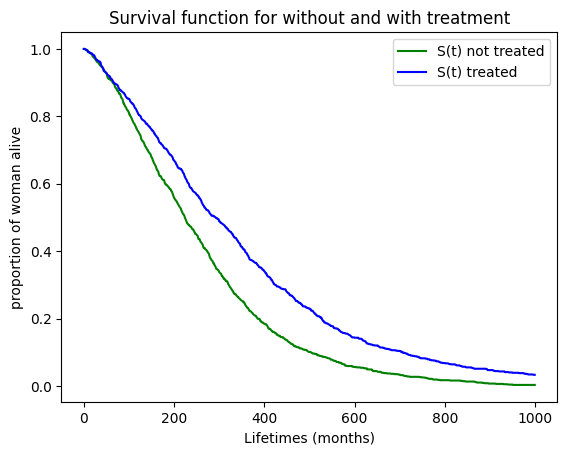

In [22]:
n_women = 1000
Q_treated = np.array([
    [-0.00475,  0.0025,  0.00125, 0,      0.001],
    [0,      -0.007,   0,  0.002,  0.005],
    [0,       0,      -0.008,  0.003,  0.005],
    [0,       0,       0,     -0.009,  0.009],
    [0,       0,       0,      0,      0]
])

survival_distribution1, mean_survival_time1, empirical1 = continous_time_state_distribution(n_women, Q_treated)

S_treated = [1 - empirical1[i] for i in range(len(empirical1))]

plt.plot(S, color="green", label='S(t) not treated')
plt.plot(S_treated, color="blue", label='S(t) treated')
plt.ylabel('proportion of woman alive')
plt.xlabel('Lifetimes (months)')
plt.legend()
plt.title('Survival function for without and with treatment')
plt.show()

## 11

The discrete model assume at max one transistion per month. In the CTMC models transistion happens according to an exponential distribution. This is a more realistic scenario as the time between transistion is more or less accelerated vary for the women. However this is itself an assumption of how the time between transistions should be distributed. 

Maybe mention that the exponential distribution is memoryless. The probability of transistion is only dependent on the current state, and not when the women transistioned to that state. consider a women who transistion quickly from surgery to local and distant recurrence, this would seem like the dieseae accelarating. But her probability of transistion to the death state is not dependent on that. 

The problem suggest that the time between transistion should be distributed by Erlang. Erlang is the sum of independent exponentially distributed random variables. The probability of transistioning could be modelleded such that the women have to enter a Erlang chain of exponential distributed parameters and then take the sum of that. not entirely sharp here.... 

## 12

In [25]:
def development_of_state(Q):
    state = 0 
    time = 0 
    series = [(state,time)] #simulated unit has its state connected to an entry time. 

    while state != 4: 
        transition_time = np.random.exponential(1/-Q[state][state])
        time += transition_time

        prop_list = [-q / Q[state][state] for q in Q[state][state+1:]]
        state = np.random.choice(np.arange(state+1, 5), p=prop_list)

        series.append((state, time)) #when a transistion happen. state and time are added to the units series. 
    
    return series

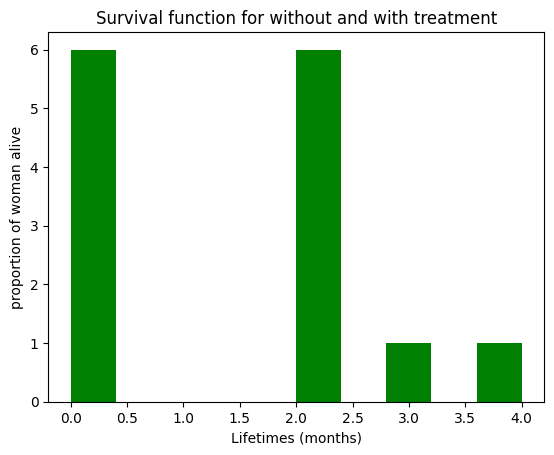

In [26]:
def state_vector(series):
    observed_state = [] #stores the observed states in order. should always end with 4 = death. 
    time = 0 
    while True:
        state = series[0][0] #starting in state (0,0)
        for (state_in_series, transistion_timestamp) in series:
            if transistion_timestamp <= time:
                state = state_in_series

        observed_state.append(state) 
        if state == 4:
            break
        time += 48 #months increment. correspond to 4 years. 
    return observed_state

series = [development_of_state(Q) for _ in range(1)]
ob = [state_vector(k) for k in series]
plt.hist(ob, color="green", label='S(t) not treated')
plt.ylabel('proportion of woman alive')
plt.xlabel('Lifetimes (months)')

plt.title('Survival function for without and with treatment')
plt.show()

## 13

In [30]:
#values for 13
series = [development_of_state(Q) for _ in range(1000)] #1000 woman noted state vs time 
observed_development = [state_vector(k) for k in series ] 

In [33]:
def rejection_sample(start_state, stop_state,Q, period = 48):

    while True:
        state = start_state 
        t = 0 
        jumps = []
        time_spend_in_state = {}

        while t < period:
            if state == 4:
                break
            wait = np.random.exponential(1 / -Q[state][state])

            if t + wait >= period:
                time_spend_in_state[state] = time_spend_in_state.get(state,0) + (period - t)
                break
            
            time_spend_in_state[state] = time_spend_in_state.get(state,0) + wait
            t += wait
            probabilities = [-q / Q[state][state] for q in Q[state][state+1:]]
            state = np.random.choice(np.arange(state+1, 5), p=probabilities)
            jumps.append(state)
        
        if state == stop_state:
            return jumps, time_spend_in_state



jumps, sojourns = rejection_sample(0, 1, Q)
print("jumps:", jumps)
print("sojourns:", sojourns)

jumps: [1]
sojourns: {0: 46.43426821958533, 1: 1.5657317804146729}


In [78]:
def series_output(observed_dev, Q):
    all_jumps = []
    all_time = {}

    for i in range(len(observed_dev)-1): #number of jumps 
        start = observed_dev[i]
        end = observed_dev[i+1]

        jumps, all_time = rejection_sample(start, end, Q)
        
        prev = start
        for j in jumps:
            all_jumps.append((prev, j))
            prev = j

        for state, time in sojourns.items():
            all_time[state] = all_time.get(state, 0) + time

    return all_jumps, all_time

jumps, sojourns = series_output(observed_development[0], Q)
print("jumps:", jumps)
print("sojourns:", sojourns)
print(observed_development[0])

jumps: [(0, 4)]
sojourns: {0: 159.9383664256101, 1: 98.3161447688554, 3: 30.54512710318085, 2: 35.68126536548677}
[0, 0, 0, 0, 4]


In [79]:
def summarize(all_results):
    N = {}   # N[(i,j)] = total jumps from i to j
    S = {}   # S[i] = total time in state i

    for jumps, sojourns in all_results:
        for (i, j) in jumps:
            N[(i,j)] = N.get((i,j), 0) + 1
        for state, time in sojourns.items():
            S[state] = S.get(state, 0) + time

    return N, S

all_results = [series_output(obs, Q) for obs in observed_development]
N, S = summarize(all_results)
print(N)
print(S)

{(0, 4): 104, (0, 2): 314, (2, 3): 209, (3, 4): 364, (0, 1): 582, (1, 3): 155, (1, 2): 228, (2, 4): 333, (1, 4): 199}
{0: 163841.60356600682, 1: 103052.08288649032, 3: 38191.283531013534, 2: 44121.79392002353}


In [81]:
def update_Q(N, S):
    Q_new = np.zeros((5, 5))
    
    for (i, j), count in N.items():
        if i != j:
            Q_new[i][j] = count / S[i]
    
    # fill diagonals so rows sum to zero
    for i in range(5):
        Q_new[i][i] = -sum(Q_new[i][j] for j in range(5) if j != i)
    
    return Q_new

Q_new = update_Q(N, S)
print(Q_new)

[[-0.00610346  0.00355221  0.00191649  0.          0.00063476]
 [ 0.         -0.00564763  0.00221247  0.00150409  0.00193106]
 [ 0.          0.         -0.01228418  0.00473689  0.00754729]
 [ 0.          0.          0.         -0.00953097  0.00953097]
 [ 0.          0.          0.          0.         -0.        ]]


In [86]:
Q_current = Q_new  # use Q_new as initial guess, or use Q directly

for iteration in range(5000):
    all_results = [series_output(obs, Q_current) for obs in observed_development]
    N, S = summarize(all_results)
    Q_next = update_Q(N, S)
    
    # check convergence
    diff = np.max(np.abs(Q_current - Q_next))
    print(f"Iteration {iteration}, max diff: {diff:.6f}")
    
    if diff < 1e-3:
        print("Converged!")
        break
    
    Q_current = Q_next

print("Estimated Q:")
print(Q_current)
print("True Q:")
print(Q)

Iteration 0, max diff: 0.001360
Iteration 1, max diff: 0.000309
Converged!
Estimated Q:
[[-0.00609928  0.00309843  0.00226283  0.          0.00073801]
 [ 0.         -0.00495462  0.0021457   0.00119964  0.00160928]
 [ 0.          0.         -0.01364384  0.00526361  0.00838023]
 [ 0.          0.          0.         -0.00916813  0.00916813]
 [ 0.          0.          0.          0.         -0.        ]]
True Q:
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]
